# Approach 3: Rule-based Normalization → PhoBERT Fine-tuning

**Model:** `vinai/phobert-base` — BERT pre-trained on formal Vietnamese text (news, Wikipedia)  
**Hypothesis:** Explicit rule-based normalization converts informal customer chat into the formal register PhoBERT was trained on, compensating for its lack of social-media pre-training.

| Stage | Description |
|---|---|
| **Normalization** | Teen code → standard Vietnamese, protect English brand names |
| **Word segmentation** | underthesea segments words (`hà nội` → `hà_nội`) to match PhoBERT's pre-training |
| **Compositional augmentation** | Synthesize rare multi-label combos by joining single-label sentences |
| **Multi-label augmentation** | Duplicate existing multi-label samples 2× in training |
| **Random token masking** | Drop 15% of tokens per sample, add 1 masked copy to training |
| **PhoBERT fine-tuning** | BCEWithLogitsLoss, sigmoid output, frozen lower layers, per-class threshold tuning |

**Research question:** Can explicit preprocessing make a formal-text BERT (PhoBERT) competitive with a social-media BERT (ViSoBERT, Approach 2)?

**Note:** Word segmentation uses **underthesea** (pure Python, no Java) instead of VnCoreNLP/RDRSegmenter — it avoids the Java dependency while still giving PhoBERT the word-segmented input it was pre-trained on.

**Prerequisite:** Run `data_preparation/data_split.ipynb` first.

In [9]:
# Requirements for this notebook
# See requirements.txt at the project root for the full list
!pip install torch transformers scikit-learn numpy pandas matplotlib seaborn joblib --quiet
!pip install hf_xet --quiet          # faster Hugging Face downloads
!pip install underthesea --quiet     # (A) Vietnamese word segmentation — pure Python, no Java

In [10]:
# Running on the Colab runtime — mount Google Drive so the kernel can read final_data.
# (The Colab kernel is a remote Linux VM and cannot see your local D: drive.)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import json
import os
import re
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import f1_score, hamming_loss, accuracy_score, classification_report

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'vinai/phobert-base'

# final_data lives on Google Drive for this Colab setup. The resolver tries the
# Drive path first, then local paths (so the same notebook also works if you ever
# switch to a local kernel). Make sure final_data is uploaded to DRIVE_DATA below.
DRIVE_DATA = '/content/drive/MyDrive/Colab Notebooks/final_data'

def resolve_data_dir():
    tried = []
    for p in [DRIVE_DATA, '../final_data', 'final_data', './final_data']:
        tried.append(os.path.abspath(p))
        if os.path.exists(os.path.join(p, 'train.jsonl')):
            return p
    d = os.path.abspath('.')
    for _ in range(6):                       # walk up to 6 parent levels
        cand = os.path.join(d, 'final_data')
        tried.append(cand)
        if os.path.exists(os.path.join(cand, 'train.jsonl')):
            return cand
        d = os.path.dirname(d)
    raise FileNotFoundError(
        'Could not locate final_data/train.jsonl.\n'
        f'  Current working dir: {os.getcwd()}\n'
        '  Tried:\n    ' + '\n    '.join(tried) +
        f'\n  -> On Colab, upload your final_data folder to:\n     {DRIVE_DATA}\n'
        '     (or edit DRIVE_DATA above to match where you put it on Drive).')

DATA_DIR = resolve_data_dir()

print(f'Device  : {DEVICE}')
print(f'Model   : {MODEL_NAME}')
print(f'CWD     : {os.getcwd()}')
print(f'DATA_DIR: {os.path.abspath(DATA_DIR)}')

Device  : cuda
Model   : vinai/phobert-base
CWD     : /content
DATA_DIR: /content/drive/MyDrive/Colab Notebooks/final_data


## 1. Load Pre-split Data

In [12]:
def load_jsonl(path):
    texts, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            texts.append(item['text'])
            labels.append(item['cats'])
    return texts, labels

train_texts, train_labels = load_jsonl(f'{DATA_DIR}/train.jsonl')
val_texts,   val_labels   = load_jsonl(f'{DATA_DIR}/val.jsonl')
test_texts,  test_labels  = load_jsonl(f'{DATA_DIR}/test.jsonl')

mlb     = joblib.load(f'{DATA_DIR}/mlb.joblib')
y_train = mlb.transform(train_labels).astype(np.float32)
y_val   = mlb.transform(val_labels).astype(np.float32)
y_test  = mlb.transform(test_labels).astype(np.float32)

print(f'Train : {len(train_texts):4d} samples')
print(f'Val   : {len(val_texts):4d} samples')
print(f'Test  : {len(test_texts):4d} samples')
print(f'Labels: {len(mlb.classes_)} classes')

Train : 3605 samples
Val   :  454 samples
Test  :  450 samples
Labels: 32 classes


## 2. Rule-based Normalization + Word Segmentation

Converts informal Vietnamese to the standard register PhoBERT was pre-trained on.

**Pipeline:**
1. Lowercase
2. Collapse repeated characters (`ơiiii` → `ơii`)
3. For each token — if it matches ASCII pattern and is NOT in the teen code dict, keep as-is (brand name / English word protection)
4. Otherwise apply teen code substitution
5. **(A) Word segmentation** with underthesea (`hà nội` → `hà_nội`) — PhoBERT was pre-trained on segmented text, so this matches its input format

**English token protection** ensures `lego`, `ferrari`, `ship`, `box`, `ok` pass through unchanged.

In [13]:
TEEN_CODE = {
    # Negation / modal
    'k'    : 'không',  'ko'   : 'không',  'kh'   : 'không',
    'khum' : 'không',  'hum'  : 'không',  'kum'  : 'không',
    # Ability
    'đc'   : 'được',   'dc'   : 'được',
    # Prepositions / pronouns
    'vs'   : 'với',
    'b'    : 'bạn',    'm'    : 'mình',
    # Domain-specific
    'sốp'  : 'shop',   'sốc'  : 'shop',
    'ck'   : 'chuyển khoản',
    'rep'  : 'trả lời',
    'sp'   : 'sản phẩm',
    'mn'   : 'mọi người',
    # Particles / adverbs
    'r'    : 'rồi',    'rui'  : 'rồi',
    'nha'  : 'nhé',    'nhen' : 'nhé',
}

# (A) Word segmentation for PhoBERT.
# PhoBERT was pre-trained on word-segmented text (RDRSegmenter), so feeding
# segmented input ("hà nội" -> "hà_nội") matches its register and typically
# gains 1-3 F1. We use underthesea (pure Python, no Java) with a graceful
# fallback so the pipeline still runs if the package is unavailable.
USE_SEGMENTATION = True
try:
    from underthesea import word_tokenize as _uts_tokenize
    def word_segment(text: str) -> str:
        return _uts_tokenize(text, format='text')
    print('Word segmentation: underthesea ENABLED')
except Exception as _seg_err:
    USE_SEGMENTATION = False
    def word_segment(text: str) -> str:
        return text
    print(f'Word segmentation: DISABLED (underthesea unavailable: {_seg_err})')

def normalize(text: str) -> str:
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)   # collapse repeated chars
    tokens = text.split()
    result = []
    for token in tokens:
        # ASCII-only tokens not in the dict are brand names / English words — keep
        if re.match(r'^[a-z0-9\-]+$', token) and token not in TEEN_CODE:
            result.append(token)
        else:
            result.append(TEEN_CODE.get(token, token))
    out = ' '.join(result)
    return word_segment(out) if USE_SEGMENTATION else out   # (A) segment as final step

# Show before / after examples
examples = [
    'sốp ơi còn hàng k ạ',
    'b có hình ảnh thực tế sp này kh ạ',
    'shop còn hàng con ferrari ko ạ',
    'cho e đặt nha, ck dc kh ạ',
    'rep giúp e vs ạ',
]
for text in examples:
    print(f'Before: {text}')
    print(f'After : {normalize(text)}')
    print()

Word segmentation: underthesea ENABLED
Before: sốp ơi còn hàng k ạ
After : shop ơi còn hàng_không ạ

Before: b có hình ảnh thực tế sp này kh ạ
After : bạn có hình_ảnh thực_tế sản_phẩm này không ạ

Before: shop còn hàng con ferrari ko ạ
After : shop còn hàng con ferrari không ạ

Before: cho e đặt nha, ck dc kh ạ
After : cho e đặt nha , chuyển_khoản được không ạ

Before: rep giúp e vs ạ
After : trả_lời giúp e với ạ



In [14]:
norm_train = [normalize(t) for t in train_texts]
norm_val   = [normalize(t) for t in val_texts]
norm_test  = [normalize(t) for t in test_texts]
print('Normalization applied to all splits.')

Normalization applied to all splits.


## 3. Multi-label Augmentation

Two complementary strategies, applied to the **training set only** (val and test use normalized text, un-augmented):

1. **Duplication** — duplicates existing multi-label samples 2× and rare-class (<80) samples 2×, same as Approaches 1 and 2.
2. **(C) Compositional augmentation** — *synthesizes new* multi-label samples by joining two single-label sentences with a natural connector. This teaches rare intent combinations (e.g. `ask_shipping_fee` + `ask_order_wait_time`) that duplication alone cannot, since those combos barely exist in the data.

In [15]:
multi_idx    = [i for i, l in enumerate(train_labels) if len(l) > 1]
extra_texts  = [norm_train[i]  for i in multi_idx] * 2
extra_labels = [train_labels[i] for i in multi_idx] * 2

aug_texts  = norm_train + extra_texts
aug_labels = train_labels + extra_labels

# Oversample rare classes (< 80 training samples) — 2 extra copies per sample
RARE_THRESHOLD = 80
class_counts  = y_train.sum(axis=0)
rare_cls_idx  = np.where(class_counts < RARE_THRESHOLD)[0]
rare_cls_names = [mlb.classes_[i] for i in rare_cls_idx]

rare_texts, rare_label_lists = [], []
for text, lbl_vec, lbl_list in zip(norm_train, y_train, train_labels):
    if any(lbl_vec[j] == 1 for j in rare_cls_idx):
        rare_texts.extend([text] * 2)
        rare_label_lists.extend([lbl_list] * 2)

aug_texts  += rare_texts
aug_labels += rare_label_lists

print(f'Original train : {len(norm_train)}')
print(f'Multi-label    : {len(multi_idx)} → +{len(multi_idx) * 2} copies')
print(f'Rare classes (<{RARE_THRESHOLD}): {rare_cls_names}')
print(f'Rare samples   : {len(rare_texts) // 2} unique → +{len(rare_texts)} copies')
print(f'Augmented total: {len(aug_texts)}')

Original train : 3605
Multi-label    : 387 → +774 copies
Rare classes (<80): ['ask_final_price', 'ask_find_product', 'ask_gift_package', 'ask_shipping_fee', 'customer_reject']
Rare samples   : 236 unique → +472 copies
Augmented total: 4851


In [16]:
# (C) Compositional multi-label augmentation
# The duplication above only copies EXISTING multi-label samples — rare intent
# *combinations* stay rare (e.g. shipping_fee + wait_time has just 4 train samples,
# which is why "ship ... bao nhiêu với mất bao lâu" scored shipping_fee = 0.095).
# Here we synthesize NEW multi-label samples by joining two single-label sentences
# with a natural connector, directly teaching the model that these intents co-occur.
import random
random.seed(42)

CONNECTORS   = [' với ', ' và ', ', ', ' luôn ', ' rồi ', ' thêm ']
TARGET_PAIRS = [
    ('ask_shipping_fee',        'ask_order_wait_time'),
    ('ask_product_suggestion',  'provide_budget'),
    ('ask_product_availability','ask_product_price'),
    ('ask_product_image',       'ask_product_price'),
]
N_PER_PAIR = 40

# Pool of RAW single-label sentences per intent (normalized + segmented per sample below)
raw_by_intent = {}
for text, lbls in zip(train_texts, train_labels):
    if len(lbls) == 1:
        raw_by_intent.setdefault(lbls[0], []).append(text)

comp_texts, comp_labels = [], []
for a, b in TARGET_PAIRS:
    if a not in raw_by_intent or b not in raw_by_intent:
        print(f'  skip {a}+{b}: no single-label pool')
        continue
    for _ in range(N_PER_PAIR):
        ta = random.choice(raw_by_intent[a]).rstrip(' .?!,')
        tb = random.choice(raw_by_intent[b])
        # normalize() now also segments, so segment the whole synthetic sentence at once
        comp_texts.append(normalize(ta + random.choice(CONNECTORS) + tb))
        comp_labels.append([a, b])

aug_texts  += comp_texts
aug_labels += comp_labels

print(f'Compositional pairs : {len(TARGET_PAIRS)} target combos')
print(f'Synthesized         : +{len(comp_texts)} multi-label samples')
print(f'Augmented total     : {len(aug_texts)}')
if comp_texts:
    print(f'Example             : {comp_texts[0]}  ->  {comp_labels[0]}')

Compositional pairs : 4 target combos
Synthesized         : +160 multi-label samples
Augmented total     : 5011
Example             : tiền giao hàng là bao_nhiêu thêm bao_giờ hàng tới nơi ?  ->  ['ask_shipping_fee', 'ask_order_wait_time']


## 4. Random Token Masking

Randomly drops tokens with probability 15%, creating one additional masked copy of the augmented training set.  

Combined with normalization, masking prevents the model from over-fitting to specific normalized trigger words — it must learn to classify from partial context.

In [17]:
MASK_PROB = 0.15

def random_mask(text: str, mask_prob: float = MASK_PROB, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    tokens = text.split()
    kept = [t for t in tokens if rng.random() > mask_prob]
    return ' '.join(kept) if kept else text  # never return empty string

rng = np.random.default_rng(42)
masked_texts = [random_mask(t, rng=rng) for t in aug_texts]

masked_train_texts  = aug_texts + masked_texts
masked_train_labels = aug_labels + aug_labels
y_masked = mlb.transform(masked_train_labels).astype(np.float32)

print(f'Augmented train : {len(aug_texts)}')
print(f'After masking   : {len(masked_train_texts)} (1 masked copy added)')
print(f'\nExample:')
print(f'  Original: {aug_texts[0]}')
print(f'  Masked  : {masked_texts[0]}')

Augmented train : 5011
After masking   : 10022 (1 masked copy added)

Example:
  Original: chị ưu_tiên gửi batch mới nhất giúp em .
  Masked  : chị ưu_tiên gửi batch nhất giúp em


## 5. Tokenizer and DataLoaders

PhoBERT uses a BPE tokenizer trained on Vietnamese text.  
Dynamic padding per batch keeps average sequence length short and training fast.

In [18]:
MAX_LEN    = 128
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print(f'Vocab size: {tokenizer.vocab_size:,}')

class IntentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = texts
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    encoding = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=MAX_LEN,
        return_tensors='pt',
    )
    return encoding, torch.stack(labels)

train_ds = IntentDataset(masked_train_texts, y_masked)
val_ds   = IntentDataset(norm_val,           y_val)
test_ds  = IntentDataset(norm_test,          y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Vocab size: 64,000
Train batches: 314
Val batches  : 15
Test batches : 15


## 6. Model

PhoBERT-base + linear classification head:
```
Normalized text → PhoBERT → [CLS] (768-dim) → Dropout(0.3) → Linear(768→32)
```

`classifier_dropout=0.3` increases regularization on the classification head — important because the ~5000-sample dataset is small relative to the 135M parameter model.

**(B) Layer freezing:** the embeddings and the first 4 of 12 encoder layers are frozen. They already encode generic Vietnamese syntax from pre-training, so freezing them reduces the trainable parameter count, speeds up training, and curbs the memorization that previously drove train loss toward zero.

In [19]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(mlb.classes_),
    problem_type='multi_label_classification',
    classifier_dropout=0.3,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

# (B) Freeze embeddings + the lowest encoder layers to fight memorization
# (train loss was collapsing to ~0.003 while val F1 stalled ~0.87). Lower layers
# encode generic Vietnamese syntax already well-learned in pre-training; only the
# upper layers + classification head need to adapt to this 32-intent task.
FREEZE_LAYERS = 4   # of PhoBERT-base's 12 encoder layers (0 = freeze nothing)
for p in model.roberta.embeddings.parameters():
    p.requires_grad = False
for layer in model.roberta.encoder.layer[:FREEZE_LAYERS]:
    for p in layer.parameters():
        p.requires_grad = False

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Frozen: embeddings + first {FREEZE_LAYERS} encoder layers')
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

Frozen: embeddings + first 4 encoder layers
Total parameters    : 135,022,880
Trainable parameters: 57,318,176 (42.5%)


## 7. Training

| Hyperparameter | Value |
|---|---|
| Learning rate | 2e-5 |
| Max epochs | 30 (early stopping patience = 6) |
| Warmup | 10% of total steps |
| Weight decay | 0.05 *(B)* |
| Frozen layers | embeddings + first 4 encoder layers *(B)* |
| Gradient clipping | 1.0 |
| Dropout on CLS | 0.3 |

*(B) Epochs reduced from 100→30 so the linear LR schedule decays; weight decay raised and lower layers frozen to curb the overfitting seen previously (train loss → ~0.003 while val F1 stalled).*

In [20]:
# (B) EPOCHS lowered 100 -> 30 so the linear LR schedule actually decays.
# Previously total_steps was sized for 100 epochs but training early-stopped ~25,
# leaving LR stuck near its peak (only ~25% through the schedule, barely decaying).
EPOCHS       = 30
LR           = 2e-5
WARMUP_RATIO = 0.1
PATIENCE     = 6
WEIGHT_DECAY = 0.05   # (B) stronger L2 regularization (was 0.01) to curb overfitting

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

# Only optimize parameters left trainable after the layer freeze above
trainable = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# Weighted BCE — upweights rare classes proportional to neg/pos ratio, capped at 10×
pos_counts = torch.tensor(y_masked.sum(axis=0), dtype=torch.float32)
neg_counts = len(y_masked) - pos_counts
pos_weight  = torch.clamp(neg_counts / pos_counts.clamp(min=1), max=10.0).to(DEVICE)
criterion   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f'Epochs       : {EPOCHS} (patience {PATIENCE})')
print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')
print(f'Weight decay : {WEIGHT_DECAY}')
print(f'Top-5 highest pos_weight (sparsest classes):')
for cls, w in sorted(zip(mlb.classes_, pos_weight.cpu().tolist()), key=lambda x: -x[1])[:5]:
    print(f'  {cls:<35} {w:.2f}x')

Epochs       : 30 (patience 6)
Total steps  : 9420
Warmup steps : 942
Weight decay : 0.05
Top-5 highest pos_weight (sparsest classes):
  Goodbye                             10.00x
  add_product                         10.00x
  agree                               10.00x
  agree_order                         10.00x
  ask_final_price                     10.00x


In [21]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    for encoding, labels in loader:
        encoding = {k: v.to(device) for k, v in encoding.items()}
        labels   = labels.to(device)
        logits   = model(**encoding).logits
        loss     = criterion(logits, labels)   # weighted BCE (replaces outputs.loss)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device, thresholds=0.5):
    model.eval()
    all_proba, all_labels = [], []
    with torch.no_grad():
        for encoding, labels in loader:
            encoding = {k: v.to(device) for k, v in encoding.items()}
            logits   = model(**encoding).logits
            proba    = torch.sigmoid(logits).cpu().numpy()
            all_proba.append(proba)
            all_labels.append(labels.numpy())
    all_proba  = np.vstack(all_proba)
    all_labels = np.vstack(all_labels)
    preds      = (all_proba >= thresholds).astype(int)
    macro_f1   = f1_score(all_labels, preds, average='macro', zero_division=0)
    return macro_f1, all_proba, all_labels

In [22]:
train_losses  = []
val_macro_f1s = []
best_val_f1   = 0.0
best_epoch    = 0
no_improve    = 0

for epoch in range(1, EPOCHS + 1):
    train_loss           = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_f1, _, _         = evaluate(model, val_loader, DEVICE, thresholds=0.5)

    train_losses.append(train_loss)
    val_macro_f1s.append(val_f1)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1 = val_f1
        best_epoch  = epoch
        no_improve  = 0
        torch.save(model.state_dict(), 'results/best_model.pt')
    else:
        no_improve += 1

    flag = ' *saved*' if improved else ''
    print(f'Epoch {epoch:2d}/{EPOCHS}  |  Train Loss: {train_loss:.4f}  |  Val Macro-F1: {val_f1:.4f}{flag}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
        break

print(f'\nBest Val Macro-F1: {best_val_f1:.4f} at epoch {best_epoch}')

Epoch  1/30  |  Train Loss: 0.8398  |  Val Macro-F1: 0.0423 *saved*
Epoch  2/30  |  Train Loss: 0.6802  |  Val Macro-F1: 0.4069 *saved*
Epoch  3/30  |  Train Loss: 0.4720  |  Val Macro-F1: 0.6428 *saved*
Epoch  4/30  |  Train Loss: 0.3092  |  Val Macro-F1: 0.7028 *saved*
Epoch  5/30  |  Train Loss: 0.2159  |  Val Macro-F1: 0.7448 *saved*
Epoch  6/30  |  Train Loss: 0.1624  |  Val Macro-F1: 0.7731 *saved*
Epoch  7/30  |  Train Loss: 0.1264  |  Val Macro-F1: 0.7972 *saved*
Epoch  8/30  |  Train Loss: 0.1010  |  Val Macro-F1: 0.8159 *saved*
Epoch  9/30  |  Train Loss: 0.0827  |  Val Macro-F1: 0.8396 *saved*
Epoch 10/30  |  Train Loss: 0.0682  |  Val Macro-F1: 0.8391
Epoch 11/30  |  Train Loss: 0.0578  |  Val Macro-F1: 0.8581 *saved*
Epoch 12/30  |  Train Loss: 0.0492  |  Val Macro-F1: 0.8673 *saved*
Epoch 13/30  |  Train Loss: 0.0428  |  Val Macro-F1: 0.8669
Epoch 14/30  |  Train Loss: 0.0379  |  Val Macro-F1: 0.8689 *saved*
Epoch 15/30  |  Train Loss: 0.0327  |  Val Macro-F1: 0.8865 *sav

## 8. Training Curves

Train loss (left axis) and Val Macro-F1 (right axis) per epoch.  
Vertical dotted line marks the best epoch where the checkpoint was saved.

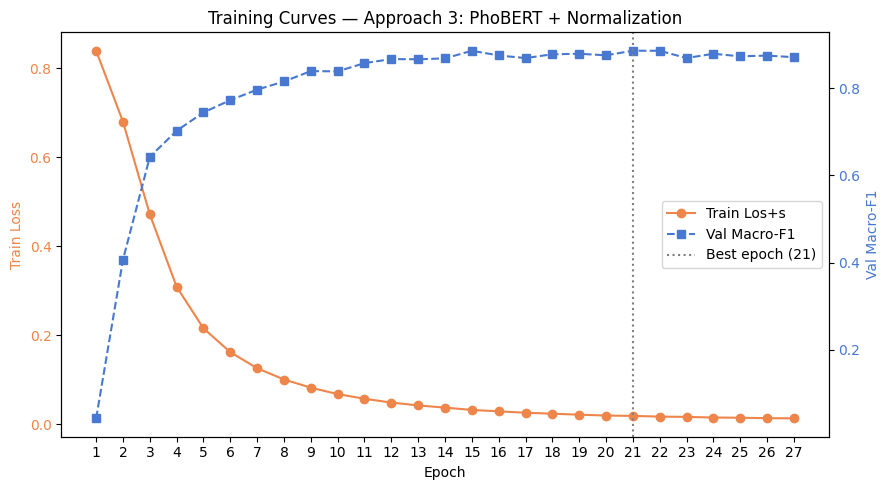

In [23]:
epochs_ran = range(1, len(train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(9, 5))
color_loss, color_f1 = '#ee854a', '#4878d0'

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color_loss)
ax1.plot(epochs_ran, train_losses, 'o-', color=color_loss, label='Train Los+s')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.set_xticks(list(epochs_ran))

ax2 = ax1.twinx()
ax2.set_ylabel('Val Macro-F1', color=color_f1)
ax2.plot(epochs_ran, val_macro_f1s, 's--', color=color_f1, label='Val Macro-F1')
ax2.tick_params(axis='y', labelcolor=color_f1)
ax2.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5,
            label=f'Best epoch ({best_epoch})')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Training Curves — Approach 3: PhoBERT + Normalization')
fig.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Per-class Threshold Tuning

Load the best checkpoint, collect sigmoid probabilities on the validation set, then find the threshold per class that maximises F1.

In [24]:
model.load_state_dict(torch.load('results/best_model.pt', map_location=DEVICE))
model.eval()

_, val_proba, val_true = evaluate(model, val_loader, DEVICE, thresholds=0.5)

thresholds = []
for i, cls in enumerate(mlb.classes_):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):   # step 0.01 (was 0.05) — finer search
        preds = (val_proba[:, i] >= t).astype(int)
        f1    = f1_score(val_true[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    thresholds.append(round(float(best_t), 2))

df_thresh = pd.DataFrame({'Class': mlb.classes_, 'Threshold': thresholds})
print(df_thresh.to_string(index=False))

                    Class  Threshold
                  Goodbye       0.88
              add_product       0.64
                    agree       0.69
              agree_order       0.17
          ask_final_price       0.11
         ask_find_product       0.30
         ask_gift_package       0.67
                ask_legit       0.07
         ask_order_status       0.22
      ask_order_wait_time       0.62
       ask_payment_method       0.20
 ask_product_availability       0.20
        ask_product_image       0.67
         ask_product_info       0.72
        ask_product_price       0.27
   ask_product_suggestion       0.55
         ask_shipping_fee       0.85
            ask_shop_info       0.39
               buy_thanks       0.58
  complain_shipping_issue       0.94
         confirm_received       0.05
          customer_reject       0.61
delivery_time_requirement       0.45
       get_product_direct       0.17
             give_product       0.84
                 greeting       0.58
 

## 10. Evaluate on Test Set

In [25]:
_, test_proba, test_true = evaluate(model, test_loader, DEVICE, thresholds=0.5)
y_pred = (test_proba >= np.array(thresholds)).astype(int)

macro_f1   = f1_score(test_true, y_pred, average='macro',  zero_division=0)
micro_f1   = f1_score(test_true, y_pred, average='micro',  zero_division=0)
h_loss     = hamming_loss(test_true, y_pred)
subset_acc = accuracy_score(test_true, y_pred)

print('=' * 55)
print('TEST RESULTS — Approach 3: PhoBERT + Normalization')
print('=' * 55)
print(f'Macro-F1        : {macro_f1:.4f}')
print(f'Micro-F1        : {micro_f1:.4f}')
print(f'Hamming Loss    : {h_loss:.4f}')
print(f'Subset Accuracy : {subset_acc:.4f}')

TEST RESULTS — Approach 3: PhoBERT + Normalization
Macro-F1        : 0.9147
Micro-F1        : 0.9128
Hamming Loss    : 0.0063
Subset Accuracy : 0.8578


In [26]:
print(classification_report(test_true, y_pred, target_names=mlb.classes_, zero_division=0))

                           precision    recall  f1-score   support

                  Goodbye       1.00      1.00      1.00        11
              add_product       1.00      1.00      1.00        11
                    agree       0.95      0.95      0.95        20
              agree_order       0.81      1.00      0.89        17
          ask_final_price       0.75      1.00      0.86         6
         ask_find_product       0.67      0.50      0.57         4
         ask_gift_package       0.86      1.00      0.92         6
                ask_legit       0.83      1.00      0.91        10
         ask_order_status       0.88      1.00      0.94        23
      ask_order_wait_time       1.00      0.92      0.96        12
       ask_payment_method       0.94      1.00      0.97        17
 ask_product_availability       0.81      1.00      0.90        26
        ask_product_image       1.00      1.00      1.00        13
         ask_product_info       0.92      0.92      0.92     

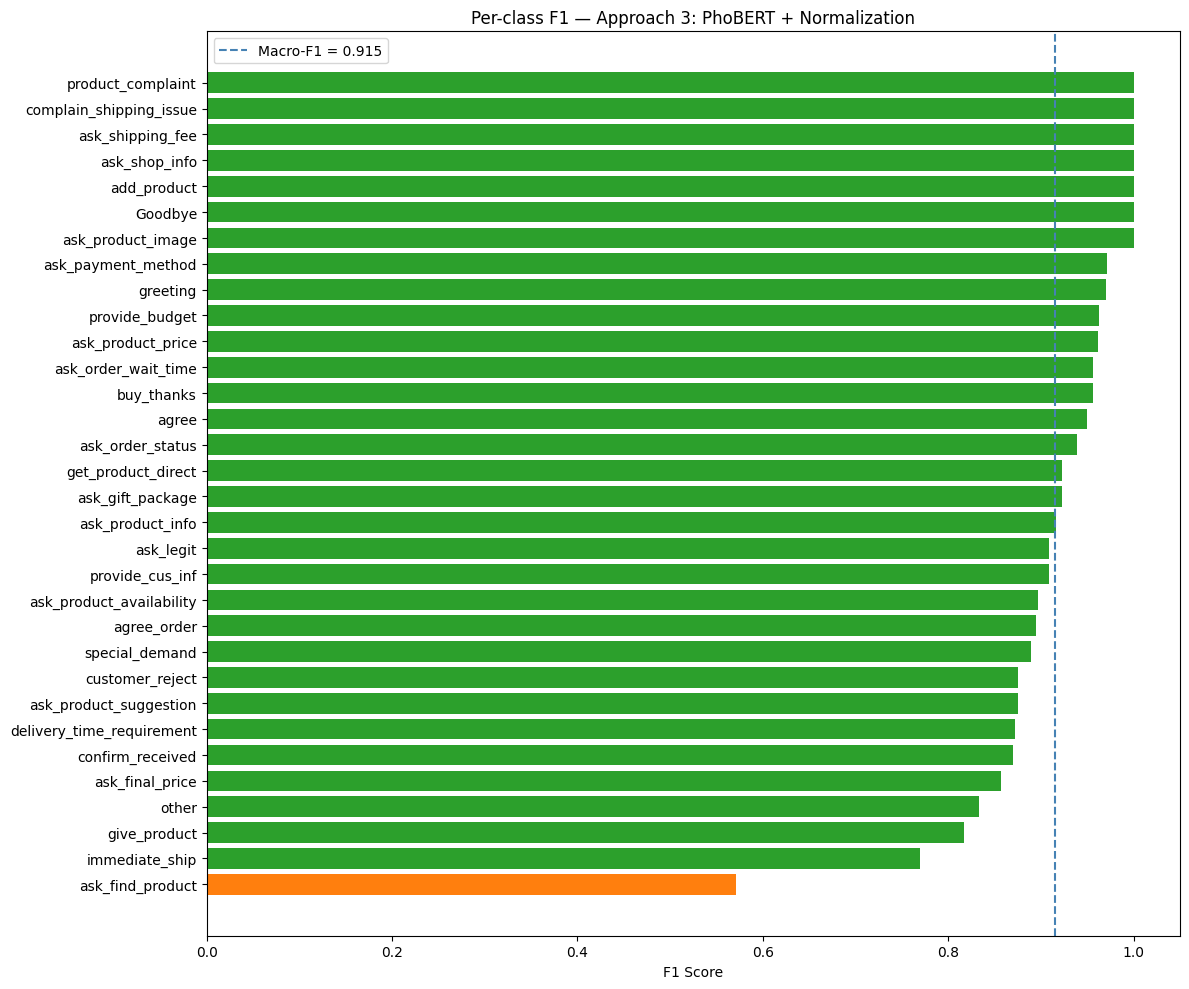

Lowest F1 : ask_find_product  (0.571)
Highest F1: product_complaint (1.000)


In [27]:
per_class_f1 = f1_score(test_true, y_pred, average=None, zero_division=0)
df_f1 = pd.DataFrame({'Label': mlb.classes_, 'F1': per_class_f1}).sort_values('F1', ascending=True)

colors = ['#d62728' if f < 0.5 else '#ff7f0e' if f < 0.7 else '#2ca02c' for f in df_f1['F1']]
plt.figure(figsize=(12, 10))
plt.barh(df_f1['Label'], df_f1['F1'], color=colors)
plt.axvline(macro_f1, color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Macro-F1 = {macro_f1:.3f}')
plt.xlabel('F1 Score')
plt.title('Per-class F1 — Approach 3: PhoBERT + Normalization')
plt.legend()
plt.tight_layout()
plt.savefig('results/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Lowest F1 : {df_f1.iloc[0]['Label']}  ({df_f1.iloc[0]['F1']:.3f})")
print(f"Highest F1: {df_f1.iloc[-1]['Label']} ({df_f1.iloc[-1]['F1']:.3f})")

## 11. Save Model and Results

In [28]:
tokenizer.save_pretrained('results/tokenizer')

metrics = {
    'approach'          : 'PhoBERT + Rule-based Normalization',
    'model_name'        : MODEL_NAME,
    'best_epoch'        : best_epoch,
    'best_val_macro_f1' : round(best_val_f1, 4),
    'thresholds'        : {k: round(float(v), 4) for k, v in zip(mlb.classes_, thresholds)},
    'macro_f1'          : round(macro_f1,   4),
    'micro_f1'          : round(micro_f1,   4),
    'hamming_loss'      : round(h_loss,     4),
    'subset_accuracy'   : round(subset_acc, 4),
    'per_class_f1'      : {k: round(float(v), 4) for k, v in zip(mlb.classes_, per_class_f1)},
    'train_losses'      : [round(x, 4) for x in train_losses],
    'val_macro_f1s'     : [round(x, 4) for x in val_macro_f1s],
}

with open('results/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print('Saved to approach3/results/:')
for name in ['best_model.pt', 'tokenizer/', 'metrics.json',
             'training_curves.png', 'per_class_f1.png']:
    print(f'  {name}')

Saved to approach3/results/:
  best_model.pt
  tokenizer/
  metrics.json
  training_curves.png
  per_class_f1.png


## 12. Test Custom Input

Reloads the best checkpoint and tokenizer from `results/` — works after a kernel restart.  
Input text is normalized with the same pipeline used during training before being passed to PhoBERT.

In [29]:
import json, re, datetime
import numpy as np
import torch
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification

_device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_tokenizer = AutoTokenizer.from_pretrained('results/tokenizer', use_fast=False)
_mlb       = joblib.load(f'{DATA_DIR}/mlb.joblib')   # uses DATA_DIR resolved in the setup cell

_model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/phobert-base',
    num_labels=len(_mlb.classes_),
    problem_type='multi_label_classification',
    classifier_dropout=0.3,
    ignore_mismatched_sizes=True,
)
_model.load_state_dict(torch.load('results/best_model.pt', map_location=_device))
_model = _model.to(_device)
_model.eval()

with open('results/metrics.json', encoding='utf-8') as f:
    _thresholds = np.array(list(json.load(f)['thresholds'].values()))

_prediction_log = []

def predict(text: str, top_k: int = 3):
    norm = normalize(text)   # apply same normalization as training
    enc  = _tokenizer(
        norm, truncation=True, padding=True,
        max_length=128, return_tensors='pt'
    )
    enc = {k: v.to(_device) for k, v in enc.items()}

    with torch.no_grad():
        logits = _model(**enc).logits
    proba     = torch.sigmoid(logits).cpu().numpy()[0]
    predicted = tuple(cls for cls, p, t in zip(_mlb.classes_, proba, _thresholds) if p >= t)
    ranked    = sorted(zip(_mlb.classes_, proba), key=lambda x: -x[1])

    _prediction_log.append({
        'timestamp' : datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input'     : text,
        'normalized': norm,
        'predicted' : list(predicted),
        'top_proba' : {label: round(float(p), 4) for label, p in ranked[:top_k]},
    })

    print(f'Input     : {text}')
    print(f'Normalized: {norm}')
    print(f'Predicted : {list(predicted) if predicted else "[none above threshold]"}')
    print(f'Top {top_k} probabilities:')
    for label, prob in ranked[:top_k]:
        marker = ' <--' if label in predicted else ''
        print(f'  {label:<35} {prob:.3f}{marker}')

print('predict() ready.  History log is in _prediction_log.')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

predict() ready.  History log is in _prediction_log.


In [30]:
# ── Change this text and re-run ──────────────────────────────────────────────
predict('sốp ơi còn hàng con ferrari k ạ')

Input     : sốp ơi còn hàng con ferrari k ạ
Normalized: shop ơi còn hàng con ferrari không ạ
Predicted : ['ask_product_availability']
Top 3 probabilities:
  ask_product_availability            0.999 <--
  give_product                        0.391
  ask_product_suggestion              0.013


In [ ]:
samples = [
    'alo',
    'Tìm cho mình một bộ cho nam, tầm 7-800k với shop ơi',
    'Ship về ngõ 20 số 30 Cát Linh mất bao lâu với bao nhiêu vậy shop',
    'Bộ này ship mất bao nhiêu với bao lâu sẽ về v ạ',
]
for text in samples:
    print('-' * 55)
    predict(text, top_k=3)
print('-' * 55)

-------------------------------------------------------
Input     : alo
Normalized: alo
Predicted : ['greeting']
Top 2 probabilities:
  greeting                            0.994 <--
  Goodbye                             0.041
-------------------------------------------------------
Input     : Tìm cho mình một bộ cho nam, tầm 7-800k với shop ơi
Normalized: tìm cho mình một bộ cho nam , tầm 7-800_k với shop ơi
Predicted : ['ask_product_suggestion', 'provide_budget']
Top 2 probabilities:
  provide_budget                      0.998 <--
  ask_product_suggestion              0.981 <--
-------------------------------------------------------
Input     : Ship về ngõ 20 số 30 Cát Linh mất bao lâu với bao nhiêu vậy shop
Normalized: ship về ngõ 20 số 30 cát linh mất bao_lâu với bao_nhiêu vậy shop
Predicted : ['ask_order_wait_time', 'ask_shipping_fee']
Top 2 probabilities:
  ask_order_wait_time                 0.994 <--
  ask_shipping_fee                    0.944 <--
-------------------------------

## 13. Prediction History Log

In [32]:
def show_log(n=None):
    entries = _prediction_log if n is None else _prediction_log[-n:]
    if not entries:
        print('Log is empty — run predict() first.')
        return
    print(f'{"#":<4} {"Timestamp":<20} {"Input":<40} {"Predicted"}')
    print('-' * 100)
    for i, e in enumerate(entries):
        idx   = len(_prediction_log) - len(entries) + i + 1
        inp   = e['input'][:38] + '..' if len(e['input']) > 40 else e['input']
        preds = ', '.join(e['predicted']) if e['predicted'] else '[none]'
        print(f'{idx:<4} {e["timestamp"]:<20} {inp:<40} {preds}')
    print(f'\nTotal entries: {len(_prediction_log)}')

show_log()

#    Timestamp            Input                                    Predicted
----------------------------------------------------------------------------------------------------
1    2026-06-13 12:08:20  sốp ơi còn hàng con ferrari k ạ          ask_product_availability
2    2026-06-13 12:08:21  shop ơi                                  greeting
3    2026-06-13 12:08:21  bao g có hàng thế ạ                      ask_order_status, ask_order_wait_time
4    2026-06-13 12:08:21  cho e đặt màu xanh với ạ                 agree_order
5    2026-06-13 12:08:21  giá con này bao nhiêu vậy shop           ask_product_price

Total entries: 5


In [33]:
LOG_PATH = 'results/prediction_log.jsonl'

def save_log(path=LOG_PATH, mode='append'):
    if not _prediction_log:
        print('Nothing to save.')
        return
    if mode == 'append':
        existing = set()
        try:
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    e = json.loads(line)
                    existing.add((e['timestamp'], e['input']))
        except FileNotFoundError:
            pass
        new = [e for e in _prediction_log if (e['timestamp'], e['input']) not in existing]
        with open(path, 'a', encoding='utf-8') as f:
            for e in new:
                json.dump(e, f, ensure_ascii=False)
                f.write('\n')
        print(f'Appended {len(new)} entries → {path}')
    else:
        with open(path, 'w', encoding='utf-8') as f:
            for e in _prediction_log:
                json.dump(e, f, ensure_ascii=False)
                f.write('\n')
        print(f'Saved {len(_prediction_log)} entries → {path}')

def clear_log():
    count = len(_prediction_log)
    _prediction_log.clear()
    print(f'Cleared {count} entries.')

print('save_log() / clear_log() ready.')

save_log() / clear_log() ready.


In [34]:
save_log()

Appended 5 entries → results/prediction_log.jsonl


In [35]:
import shutil, json
from pathlib import Path

# Save the full model (offline-capable — no need to re-download from HF)
model.load_state_dict(torch.load('results/best_model.pt', map_location=DEVICE))
model.save_pretrained('results/intent_model')
tokenizer.save_pretrained('results/intent_model')

# Copy mlb.joblib into results/ so everything zips into one self-contained file
shutil.copy(f'{DATA_DIR}/mlb.joblib', 'results/mlb.joblib')

# Zip the whole results/ folder (written to the Colab VM, which is ephemeral)
zip_path = shutil.make_archive('approach3_results', 'zip', '.', 'results')
size_mb  = Path(zip_path).stat().st_size / 1024**2
print(f'{Path(zip_path).name}  —  {size_mb:.1f} MB  (on VM: {Path(zip_path).resolve()})')

# Persist the zip to Google Drive so it survives a VM reset
DRIVE_OUT = '/content/drive/MyDrive/approach3_results.zip'
if os.path.isdir('/content/drive/MyDrive'):
    shutil.copy(zip_path, DRIVE_OUT)
    print(f'Saved to Google Drive: {DRIVE_OUT}')
else:
    print('Google Drive not mounted — zip kept on the VM only.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

approach3_results.zip  —  759.2 MB  (on VM: /content/approach3_results.zip)
Saved to Google Drive: /content/drive/MyDrive/approach3_results.zip
